# Monte Carlo — Symulacja Ryzyka Portfela

**Data analizy:** 2026-04-07  
**Horyzont symulacji:** 1 rok (252 dni handlowe)  
**Liczba symulacji:** 10 000  
**Model:** Geometric Brownian Motion (GBM) ze skorelowanymi aktywami


## Sekcja 1 — Setup i definicja portfela

In [1]:
# Instalacja zależności (odkomentuj jeśli potrzebne)
# !pip install numpy pandas matplotlib seaborn yfinance scipy

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import yfinance as yf
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Ustawienia wykresu
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('darkgrid')

print('Biblioteki załadowane pomyślnie.')

Biblioteki załadowane pomyślnie.


In [3]:
# ==============================================================
#  DEFINICJA PORTFELA
#  Format: 'TICKER': (ilość_akcji, cena_zakupu_EUR/USD/GBp)
# ==============================================================
PORTFOLIO_RAW = {
    'M7U.DE':  (10.0,  11.39),   # Nynomic — XETRA (EUR)
    'AAOI':    (1.2,  102.02),   # Applied Optoelectronics — NASDAQ (USD)
    'AXTI':    (3.0,   48.00),   # AXT Inc — NASDAQ (USD)
    'SOI.PA':  (2.1,   54.38),   # Soitec — Euronext Paris (EUR)
    'IQE.L':   (270.0,  0.2521), # IQE — LSE (GBp)
    'LITE':    (0.09, 674.90),   # Lumentum — NASDAQ (USD)
    'LNSR':    (6.0,    6.08),   # LENSAR — NASDAQ (USD)
    'IVV':     (0.02, 609.56),   # iShares Core S&P 500 ETF — NYSE (USD)
    'P4O.DE':  (1.0,    8.50),   # Plan Optik — XETRA (EUR)
}

portfolio_df = pd.DataFrame(
    [(ticker, qty, price, qty * price)
     for ticker, (qty, price) in PORTFOLIO_RAW.items()],
    columns=['Ticker', 'Ilość', 'Cena zakupu', 'Wartość (local)']
).set_index('Ticker')

total_value = portfolio_df['Wartość (local)'].sum()
portfolio_df['Udział (%)'] = (portfolio_df['Wartość (local)'] / total_value * 100).round(2)

print(f'Portfel inwestycyjny:')
print(portfolio_df.to_string())
print(f'\nŁączna wartość (ceny lokalne): {total_value:.2f}')

Portfel inwestycyjny:
         Ilość  Cena zakupu  Wartość (local)  Udział (%)
Ticker                                                  
M7U.DE   10.00      11.3900         113.9000       16.74
AAOI      1.20     102.0200         122.4240       17.99
AXTI      3.00      48.0000         144.0000       21.16
SOI.PA    2.10      54.3800         114.1980       16.78
IQE.L   270.00       0.2521          68.0670       10.00
LITE      0.09     674.9000          60.7410        8.93
LNSR      6.00       6.0800          36.4800        5.36
IVV       0.02     609.5600          12.1912        1.79
P4O.DE    1.00       8.5000           8.5000        1.25

Łączna wartość (ceny lokalne): 680.50


## Sekcja 2 — Pobieranie danych z Yahoo Finance i estymacja parametrów

In [4]:
TICKERS = list(PORTFOLIO_RAW.keys())
HISTORY_YEARS = 2  # lata historii do estymacji volatility

print(f'Pobieranie {HISTORY_YEARS} lat historii kursów dla {len(TICKERS)} aktywów...')
raw_data = yf.download(
    TICKERS,
    period=f'{HISTORY_YEARS}y',
    auto_adjust=True,
    progress=True
)['Close']

# Uzupełnij brakujące dane metodą forward-fill (weekendy, święta)
prices = raw_data.ffill().dropna(how='all')

# Raport dostępności danych
print('\nDostępność danych (% sesji z danymi):')
for t in TICKERS:
    if t in prices.columns:
        pct = prices[t].notna().mean() * 100
        print(f'  {t:10s}: {pct:.1f}%')
    else:
        print(f'  {t:10s}: BRAK DANYCH — ticker może być nieprawidłowy')

print(f'\nOkres: {prices.index[0].date()} → {prices.index[-1].date()}')
print(f'Liczba sesji: {len(prices)}')

Pobieranie 2 lat historii kursów dla 9 aktywów...


[                       0%                       ]

[                       0%                       ]

[****************      33%                       ]  3 of 9 completed

[****************      33%                       ]  3 of 9 completed

...

[**********************67%*******                ]  6 of 9 completed

[**********************78%************           ]  7 of 9 completed

[**********************89%******************     ]  8 of 9 completed

[*********************100%***********************]  9 of 9 completed


Dostępność danych (% sesji z danymi):
  M7U.DE    : 100.0%
  AAOI      : 100.0%
  AXTI      : 100.0%
  SOI.PA    : 100.0%
  IQE.L     : 100.0%
  LITE      : 100.0%
  LNSR      : 100.0%
  IVV       : 100.0%
  P4O.DE    : 100.0%

Okres: 2024-04-08 → 2026-04-07
Liczba sesji: 516


In [5]:
# Dzienne log-zwroty
log_returns = np.log(prices / prices.shift(1)).dropna()
log_returns = log_returns.dropna(axis=1, how='all')
valid_tickers = log_returns.columns.tolist()

TRADING_DAYS = 252
mu_daily    = log_returns.mean()
sigma_daily = log_returns.std()
mu_annual   = mu_daily * TRADING_DAYS
sigma_annual = sigma_daily * np.sqrt(TRADING_DAYS)

params_df = pd.DataFrame({
    'Śr. zwrot roczny (%)': (mu_annual * 100).round(2),
    'Volatility roczna (%)': (sigma_annual * 100).round(2),
    'Sharpe (przybliż.)': ((mu_annual) / sigma_annual).round(2)
})
print('Parametry aktywów (na podstawie historii):')
print(params_df.to_string())

PORTFOLIO = {t: PORTFOLIO_RAW[t] for t in valid_tickers if t in PORTFOLIO_RAW}
portfolio_tickers = [t for t in valid_tickers if t in PORTFOLIO]
quantities = np.array([PORTFOLIO[t][0] for t in portfolio_tickers])

# ── Kursy walut → USD ─────────────────────────────────────────────────────────
print('\nPobieranie kursów walut...')
fx_raw = yf.download(['GBPUSD=X', 'EURUSD=X'], period='5d', auto_adjust=True, progress=False)['Close']
gbp_usd = float(fx_raw['GBPUSD=X'].dropna().iloc[-1])
eur_usd = float(fx_raw['EURUSD=X'].dropna().iloc[-1])
print(f'  GBP/USD = {gbp_usd:.4f}  |  EUR/USD = {eur_usd:.4f}')

FX = {
    'IQE.L':  gbp_usd / 100,   # GBp → USD
    'SOI.PA': eur_usd,          # EUR → USD
    'M7U.DE': eur_usd,          # EUR → USD
    'P4O.DE': eur_usd,          # EUR → USD
}
fx_factors = np.array([FX.get(t, 1.0) for t in portfolio_tickers])

S0_raw = prices[portfolio_tickers].iloc[-1].values
S0     = S0_raw * fx_factors

portfolio_value_0 = float(S0 @ quantities)
cost_basis        = sum(PORTFOLIO[t][0] * PORTFOLIO[t][1] * FX.get(t, 1.0) for t in portfolio_tickers)
unrealized_pnl    = portfolio_value_0 - cost_basis

print(f'\n{"Ticker":10s} {"Cena (local)":>14s} {"FX":>8s} {"Cena (USD)":>12s} {"Ilość":>8s} {"Wartość":>10s}')
print('-' * 68)
for t, p_raw, fx, p_usd, qty in zip(portfolio_tickers, S0_raw, fx_factors, S0, quantities):
    print(f'{t:10s} {p_raw:>14.4f} {fx:>8.4f} {p_usd:>12.4f} {qty:>8.2f} ${p_usd*qty:>9.2f}')
print('-' * 68)
print(f'\nCost basis (USD):           ${cost_basis:.2f}')
print(f'Wartość rynkowa (dzisiaj):  ${portfolio_value_0:.2f}')
print(f'Niezrealizowany P&L:        ${unrealized_pnl:+.2f} ({unrealized_pnl/cost_basis*100:+.1f}%)')

Parametry aktywów (na podstawie historii):
        Śr. zwrot roczny (%)  Volatility roczna (%)  Sharpe (przybliż.)
Ticker                                                                 
AAOI                  109.40                 123.65                0.88
AXTI                  122.79                 107.33                1.14
IQE.L                  12.43                  84.14                0.15
IVV                    12.73                  15.95                0.80
LITE                  139.62                  73.12                1.91
LNSR                   28.69                  65.69                0.44
M7U.DE                -40.38                  51.04               -0.79
P4O.DE                 37.49                  75.37                0.50
SOI.PA                -29.78                  68.88               -0.43

Pobieranie kursów walut...


  GBP/USD = 1.3250  |  EUR/USD = 1.1571

Ticker       Cena (local)       FX   Cena (USD)    Ilość    Wartość
--------------------------------------------------------------------
AAOI             115.7150   1.0000     115.7150     1.20 $   138.86
AXTI              43.9000   1.0000      43.9000     3.00 $   131.70
IQE.L             25.5000   0.0132       0.3379   270.00 $    91.22
IVV              658.7050   1.0000     658.7050     0.02 $    13.17
LITE             796.0200   1.0000     796.0200     0.09 $    71.64
LNSR               5.7700   1.0000       5.7700     6.00 $    34.62
M7U.DE            12.7500   1.1571      14.7535    10.00 $   147.54
P4O.DE             7.1000   1.1571       8.2157     1.00 $     8.22
SOI.PA            49.0000   1.1571      56.6998     2.10 $   119.07
--------------------------------------------------------------------

Cost basis (USD):           $650.51
Wartość rynkowa (dzisiaj):  $756.04
Niezrealizowany P&L:        $+105.52 (+16.2%)


## Sekcja 3 — Macierz korelacji

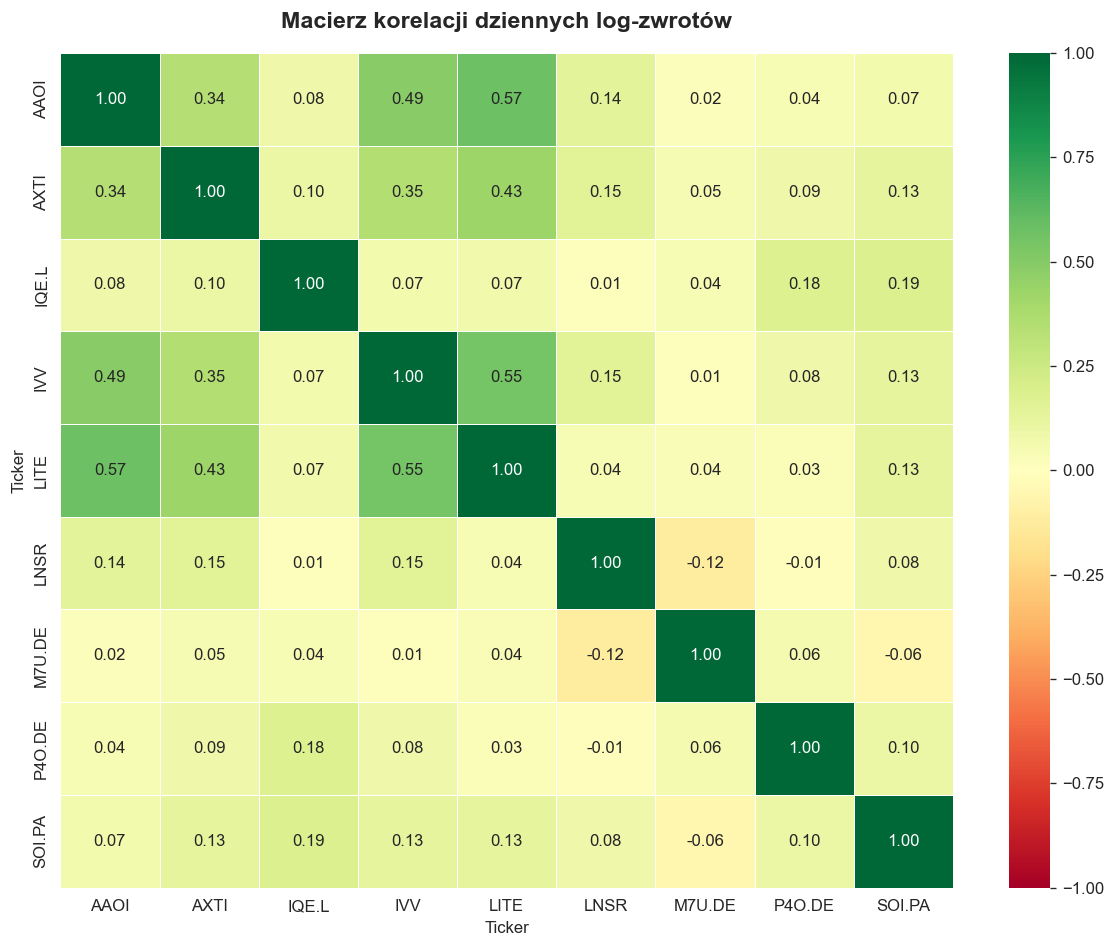


Kluczowe korelacje (wartości bezwzględne > 0.4):
  AAOI ↔ IVV: 0.487
  AAOI ↔ LITE: 0.571
  AXTI ↔ LITE: 0.426
  IVV ↔ LITE: 0.553


In [6]:
corr_matrix = log_returns.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='RdYlGn',
    vmin=-1, vmax=1,
    center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Macierz korelacji dziennych log-zwrotów', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print('\nKluczowe korelacje (wartości bezwzględne > 0.4):')
for i in range(len(corr_matrix)):
    for j in range(i+1, len(corr_matrix)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.4:
            print(f'  {corr_matrix.index[i]} ↔ {corr_matrix.columns[j]}: {val:.3f}')

## Sekcja 4 — Symulacja Monte Carlo (GBM + korelacje)

In [7]:
np.random.seed(42)

N_SIMULATIONS = 10_000
T = TRADING_DAYS  # 252 dni
dt = 1

n_assets = len(portfolio_tickers)
mu_vec    = mu_daily[portfolio_tickers].values
sigma_vec = sigma_daily[portfolio_tickers].values

# Macierz kowariancji i rozkład Cholesky'ego
cov_matrix = log_returns[portfolio_tickers].cov().values
L = np.linalg.cholesky(cov_matrix)

# Ścieżki wartości portfela: (symulacje × dni+1)
portfolio_paths = np.zeros((N_SIMULATIONS, T + 1))
portfolio_paths[:, 0] = portfolio_value_0  # start = aktualna wartość rynkowa

print(f'Wartość startowa portfela (rynkowa): ${portfolio_value_0:.2f}')
print(f'Uruchamiam {N_SIMULATIONS:,} symulacji × {T} dni...')

for sim in range(N_SIMULATIONS):
    Z_indep = np.random.standard_normal((T, n_assets))
    Z_corr  = Z_indep @ L.T  # skorelowane losowania (T × n_assets)

    drift     = (mu_vec - 0.5 * sigma_vec**2) * dt
    diffusion = sigma_vec * np.sqrt(dt) * Z_corr

    log_ret_sim  = drift + diffusion               # (T × n_assets)
    price_paths  = S0 * np.exp(np.cumsum(log_ret_sim, axis=0))  # (T × n_assets)

    portfolio_paths[sim, 1:] = price_paths @ quantities

print('Symulacja zakończona!')
print(f'Shape: {portfolio_paths.shape}')

Wartość startowa portfela (rynkowa): $756.04
Uruchamiam 10,000 symulacji × 252 dni...


Symulacja zakończona!
Shape: (10000, 253)


## Sekcja 5 — Metryki ryzyka

In [8]:
# Końcowe wartości portfela (po 252 dniach)
final_values = portfolio_paths[:, -1]
returns_pct  = (final_values - portfolio_value_0) / portfolio_value_0 * 100

# ── VaR (Value at Risk) ──────────────────────────────────────────────────────
# VaR = strata przy danym poziomie ufności (wartość dodatnia = strata)
pct5  = np.percentile(returns_pct, 5)   # 5. percentyl zwrotów
pct1  = np.percentile(returns_pct, 1)   # 1. percentyl zwrotów

var_95_pct = max(0.0, -pct5)   # strata w % (0 jeśli scenariusz 5% to nadal zysk)
var_99_pct = max(0.0, -pct1)
var_95_usd = portfolio_value_0 * var_95_pct / 100
var_99_usd = portfolio_value_0 * var_99_pct / 100

# ── CVaR / Expected Shortfall ─────────────────────────────────────────────────
tail_returns = returns_pct[returns_pct <= pct5]
cvar_95_pct  = max(0.0, -tail_returns.mean()) if len(tail_returns) else 0.0
cvar_95_usd  = portfolio_value_0 * cvar_95_pct / 100

# ── Pozostałe metryki ─────────────────────────────────────────────────────────
prob_loss    = (final_values < portfolio_value_0).mean() * 100
prob_gain20  = (returns_pct > 20).mean() * 100
prob_loss30  = (returns_pct < -30).mean() * 100

percentiles = np.percentile(final_values, [1, 5, 10, 25, 50, 75, 90, 95, 99])
pct_labels  = ['1%', '5%', '10%', '25%', '50% (mediana)', '75%', '90%', '95%', '99%']

print('=' * 62)
print('  RAPORT RYZYKA PORTFELA — Monte Carlo (10 000 symulacji)')
print('=' * 62)
print(f'\n  Wartość rynkowa (start):      ${portfolio_value_0:>10.2f}')
print(f'  Oczekiwana wartość (mediana): ${np.median(final_values):>10.2f}')
print(f'  Oczekiwana wartość (średnia): ${np.mean(final_values):>10.2f}')

print(f'\n── Value at Risk (horyzont 1 rok) ───────────────────────')
if var_95_pct == 0:
    print(f'  VaR 95%: BRAK RYZYKA STRATY — nawet scenariusz 5% to zysk ({pct5:+.1f}%)')
else:
    print(f'  VaR 95%:  strata do ${var_95_usd:.2f}  ({var_95_pct:.1f}%) przy 95% pewności')
if var_99_pct == 0:
    print(f'  VaR 99%: BRAK RYZYKA STRATY — nawet scenariusz 1% to zysk ({pct1:+.1f}%)')
else:
    print(f'  VaR 99%:  strata do ${var_99_usd:.2f}  ({var_99_pct:.1f}%) przy 99% pewności')

print(f'\n── CVaR / Expected Shortfall ────────────────────────────')
if cvar_95_pct == 0:
    print(f'  CVaR 95%: brak strat nawet w najgorszych 5% scenariuszy')
else:
    print(f'  CVaR 95%: oczekiwana strata ${cvar_95_usd:.2f} ({cvar_95_pct:.1f}%) w najgorszych 5%')

print(f'\n── Prawdopodobieństwa ───────────────────────────────────')
print(f'  P(strata w ciągu roku)  = {prob_loss:.1f}%')
print(f'  P(zysk > 20%)           = {prob_gain20:.1f}%')
print(f'  P(strata > 30%)         = {prob_loss30:.1f}%')

print(f'\n── Rozkład wartości końcowej ────────────────────────────')
for label, val in zip(pct_labels, percentiles):
    change = (val - portfolio_value_0) / portfolio_value_0 * 100
    sign = '+' if change >= 0 else ''
    print(f'  {label:>14s}: ${val:>10.2f}  ({sign}{change:.1f}%)')
print('=' * 62)

  RAPORT RYZYKA PORTFELA — Monte Carlo (10 000 symulacji)

  Wartość rynkowa (start):      $    756.04
  Oczekiwana wartość (mediana): $    957.74
  Oczekiwana wartość (średnia): $    959.24

── Value at Risk (horyzont 1 rok) ───────────────────────
  VaR 95%: BRAK RYZYKA STRATY — nawet scenariusz 5% to zysk (+19.1%)
  VaR 99%: BRAK RYZYKA STRATY — nawet scenariusz 1% to zysk (+16.3%)

── CVaR / Expected Shortfall ────────────────────────────
  CVaR 95%: brak strat nawet w najgorszych 5% scenariuszy

── Prawdopodobieństwa ───────────────────────────────────
  P(strata w ciągu roku)  = 0.0%
  P(zysk > 20%)           = 92.6%
  P(strata > 30%)         = 0.0%

── Rozkład wartości końcowej ────────────────────────────
              1%: $    878.94  (+16.3%)
              5%: $    900.14  (+19.1%)
             10%: $    913.54  (+20.8%)
             25%: $    934.05  (+23.5%)
   50% (mediana): $    957.74  (+26.7%)
             75%: $    983.31  (+30.1%)
             90%: $   1007.48  (+33.3

## Sekcja 6 — Wizualizacje

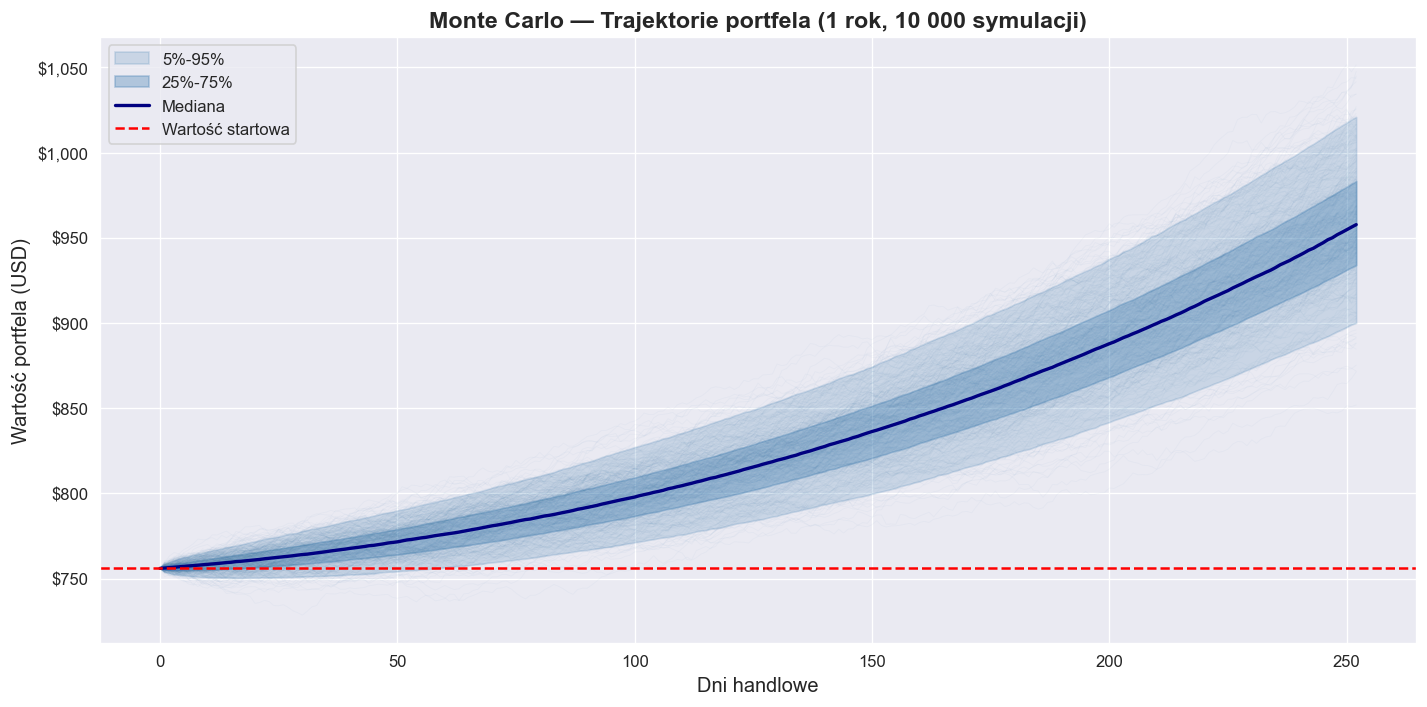

In [9]:
# ── WYKRES 1: Fan chart — ścieżki symulacji ───────────────────────────────────
days = np.arange(T + 1)
pct_5  = np.percentile(portfolio_paths, 5,  axis=0)
pct_25 = np.percentile(portfolio_paths, 25, axis=0)
pct_50 = np.percentile(portfolio_paths, 50, axis=0)
pct_75 = np.percentile(portfolio_paths, 75, axis=0)
pct_95 = np.percentile(portfolio_paths, 95, axis=0)

fig, ax = plt.subplots(figsize=(12, 6))

# 300 losowych ścieżek w tle
idx_sample = np.random.choice(N_SIMULATIONS, 300, replace=False)
for i in idx_sample:
    ax.plot(days, portfolio_paths[i], color='steelblue', alpha=0.04, linewidth=0.5)

# Pasma percentylowe
ax.fill_between(days, pct_5,  pct_95, alpha=0.2, color='steelblue', label='5%-95%')
ax.fill_between(days, pct_25, pct_75, alpha=0.35, color='steelblue', label='25%-75%')
ax.plot(days, pct_50, color='navy', linewidth=2, label='Mediana')
ax.axhline(portfolio_value_0, color='red', linewidth=1.5, linestyle='--', label='Wartość startowa')

ax.set_xlabel('Dni handlowe', fontsize=12)
ax.set_ylabel('Wartość portfela (USD)', fontsize=12)
ax.set_title('Monte Carlo — Trajektorie portfela (1 rok, 10 000 symulacji)', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

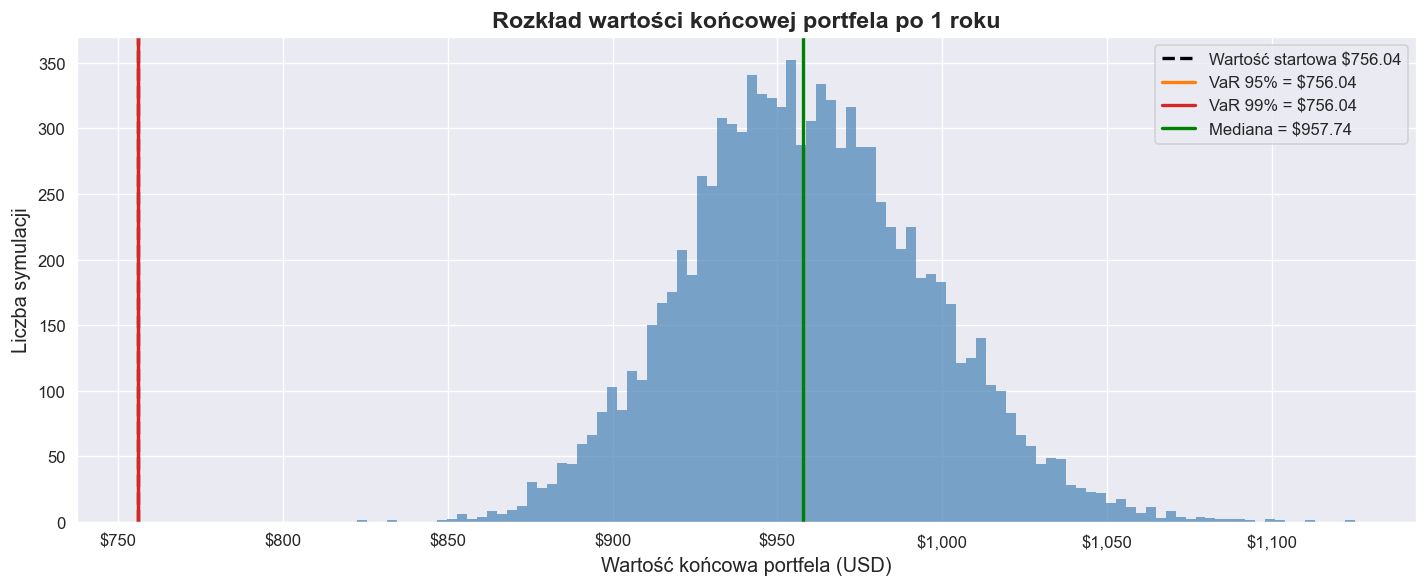

In [10]:
# ── WYKRES 2: Histogram końcowych wartości portfela z VaR ─────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

n_bins = 100
n, bins, patches = ax.hist(final_values, bins=n_bins, color='steelblue', edgecolor='none', alpha=0.7)

# Pokoloruj lewy ogon (straty poniżej VaR 95%)
var_95_value = portfolio_value_0 * (1 + var_95_pct / 100)
var_99_value = portfolio_value_0 * (1 + var_99_pct / 100)
for patch, left_edge in zip(patches, bins):
    if left_edge < var_99_value:
        patch.set_facecolor('#d62728')
    elif left_edge < var_95_value:
        patch.set_facecolor('#ff7f0e')

ax.axvline(portfolio_value_0, color='black', linewidth=2, linestyle='--', label=f'Wartość startowa ${portfolio_value_0:.2f}')
ax.axvline(var_95_value,      color='#ff7f0e', linewidth=2, linestyle='-',  label=f'VaR 95% = ${var_95_value:.2f}')
ax.axvline(var_99_value,      color='#d62728', linewidth=2, linestyle='-',  label=f'VaR 99% = ${var_99_value:.2f}')
ax.axvline(np.median(final_values), color='green', linewidth=2, linestyle='-', label=f'Mediana = ${np.median(final_values):.2f}')

ax.set_xlabel('Wartość końcowa portfela (USD)', fontsize=12)
ax.set_ylabel('Liczba symulacji', fontsize=12)
ax.set_title('Rozkład wartości końcowej portfela po 1 roku', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

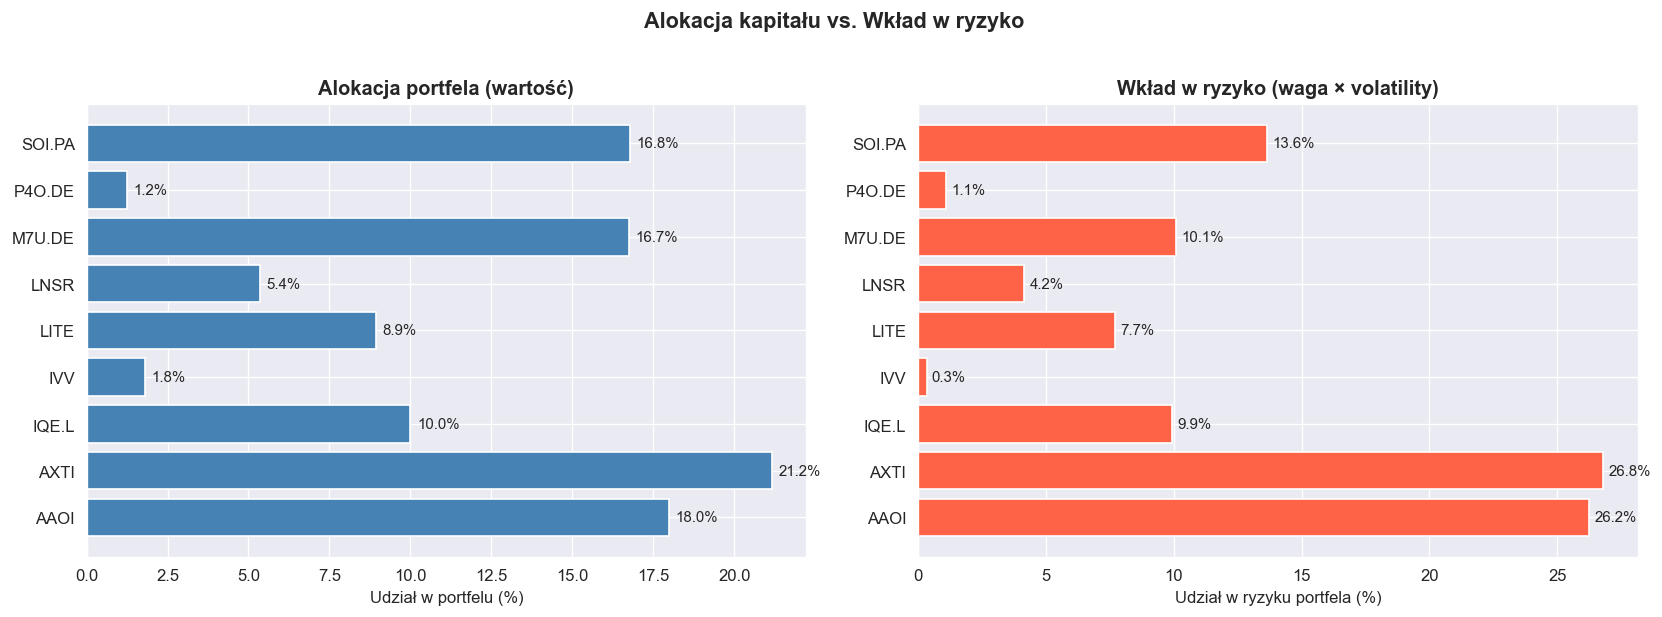

In [11]:
# ── WYKRES 3: Wkład aktywów w ryzyko portfela ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Udziały w wartości portfela
w_labels = [t for t in valid_tickers if t in PORTFOLIO]
w_vals   = np.array([PORTFOLIO[t][0] * PORTFOLIO[t][1] for t in w_labels])
w_pct    = w_vals / w_vals.sum() * 100

axes[0].barh(w_labels, w_pct, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Udział w portfelu (%)')
axes[0].set_title('Alokacja portfela (wartość)', fontweight='bold')
for i, v in enumerate(w_pct):
    axes[0].text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=9)

# Wkład w ryzyko = waga × roczna volatility
risk_contrib = np.array([w_pct[i] / 100 * sigma_annual.get(t, 0) * 100
                          for i, t in enumerate(w_labels)])
risk_pct     = risk_contrib / risk_contrib.sum() * 100

axes[1].barh(w_labels, risk_pct, color='tomato', edgecolor='white')
axes[1].set_xlabel('Udział w ryzyku portfela (%)')
axes[1].set_title('Wkład w ryzyko (waga × volatility)', fontweight='bold')
for i, v in enumerate(risk_pct):
    axes[1].text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=9)

plt.suptitle('Alokacja kapitału vs. Wkład w ryzyko', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

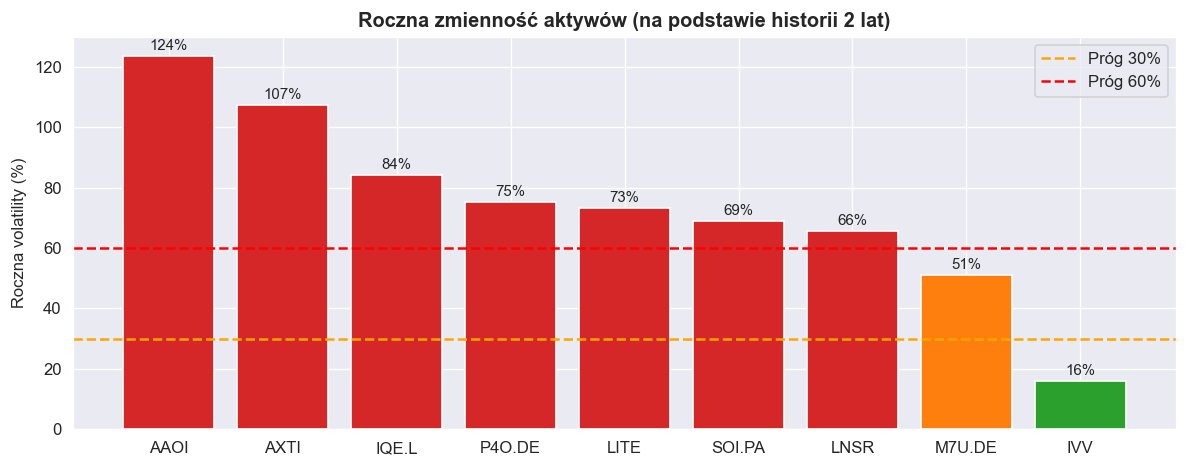


=== PODSUMOWANIE KOŃCOWE ===
Portfel o wartości $756.04 zdominowany przez aktywa fotonikaowe/półprzewodnikowe.
Wysoka koncentracja ryzyka — branża niszowa z dużą korelacją.
VaR 95%: $0.00 (-0.0%) | VaR 99%: $0.00 (-0.0%)
Prawdopodobieństwo straty w ciągu roku: 0.0%


In [12]:
# ── WYKRES 4: Roczna volatility aktywów ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))

tickers_sorted = sigma_annual.sort_values(ascending=False)
colors = ['#d62728' if v > 0.6 else '#ff7f0e' if v > 0.4 else '#2ca02c' for v in tickers_sorted]

ax.bar(tickers_sorted.index, tickers_sorted.values * 100, color=colors, edgecolor='white')
ax.axhline(30, color='orange', linewidth=1.5, linestyle='--', label='Próg 30%')
ax.axhline(60, color='red', linewidth=1.5, linestyle='--', label='Próg 60%')
ax.set_ylabel('Roczna volatility (%)')
ax.set_title('Roczna zmienność aktywów (na podstawie historii 2 lat)', fontweight='bold')
ax.legend()
for i, (t, v) in enumerate(tickers_sorted.items()):
    ax.text(i, v * 100 + 1, f'{v*100:.0f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print('\n=== PODSUMOWANIE KOŃCOWE ===')
print(f'Portfel o wartości ${portfolio_value_0:.2f} zdominowany przez aktywa fotonikaowe/półprzewodnikowe.')
print(f'Wysoka koncentracja ryzyka — branża niszowa z dużą korelacją.')
print(f'VaR 95%: ${var_95_usd:.2f} ({-var_95_pct:.1f}%) | VaR 99%: ${var_99_usd:.2f} ({-var_99_pct:.1f}%)')
print(f'Prawdopodobieństwo straty w ciągu roku: {prob_loss:.1f}%')